In [155]:
df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [156]:
df.shape


(20640, 10)

In [157]:
df.columns


Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [158]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [159]:
df.describe()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,536.838857,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,419.391878,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,297.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,643.250000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [160]:
df.isnull().sum()


longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

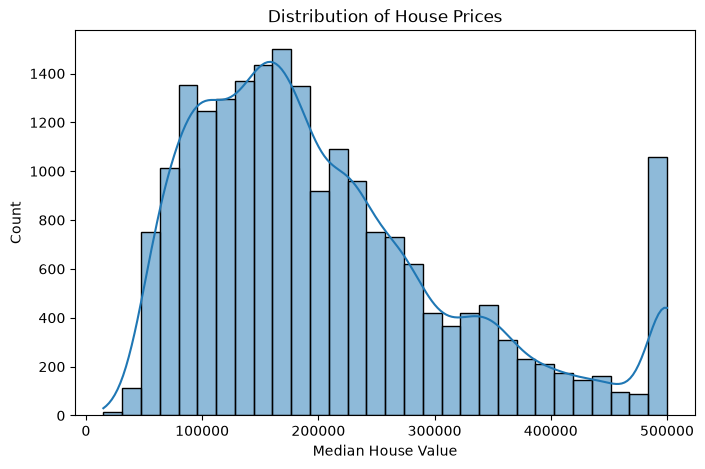

In [161]:
plt.figure(figsize=(8,5))
sns.histplot(df["median_house_value"], bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Median House Value")
plt.ylabel("Count")
plt.show()

In [162]:
df["ocean_proximity"].value_counts()


ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

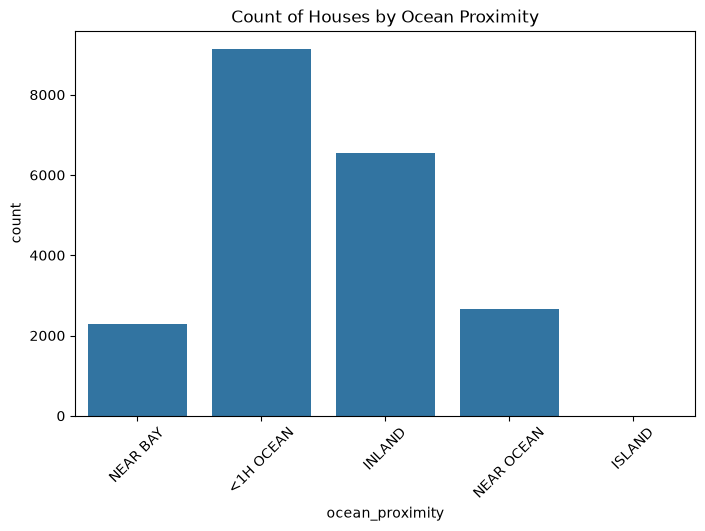

In [163]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="ocean_proximity")
plt.xticks(rotation=45)
plt.title("Count of Houses by Ocean Proximity")
plt.show()

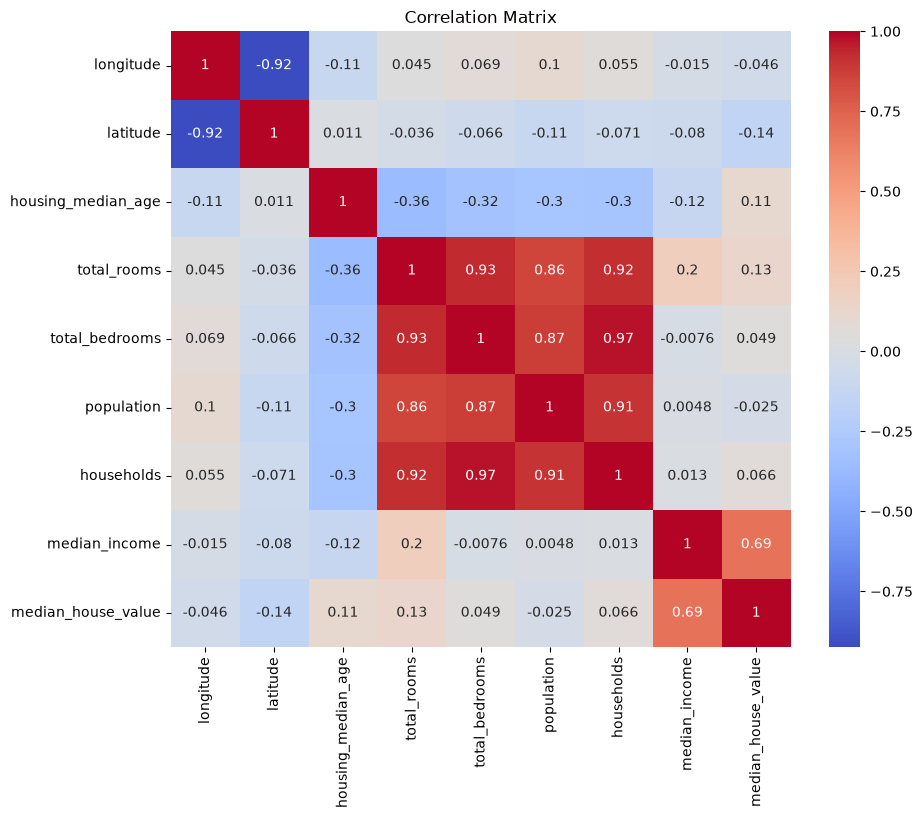

In [164]:
numeric_df = df.select_dtypes(include=["number"])
corr = numeric_df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [165]:
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].median())


In [166]:
df.isnull().sum()


longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [167]:
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

In [168]:
X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,NEAR BAY


In [169]:
y.head()

0    452600.0
1    358500.0
2    352100.0
3    341300.0
4    342200.0
Name: median_house_value, dtype: float64

In [170]:
X["ocean_proximity"].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [171]:
X = pd.get_dummies(X, columns=["ocean_proximity"], dtype=int)

In [172]:
df = pd.read_csv("../data/raw/housing.csv")


In [173]:
X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,0,0,0,1,0


In [174]:
X.sample(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
13035,-121.17,38.71,15.0,3084.0,557.0,1040.0,562.0,2.5183,0,1,0,0,0
18503,-122.03,37.18,10.0,212.0,38.0,78.0,21.0,6.0622,1,0,0,0,0
15623,-122.41,37.80,52.0,3278.0,775.0,1279.0,709.0,5.4378,0,0,0,1,0
8158,-118.12,33.81,37.0,1798.0,331.0,860.0,340.0,4.2143,1,0,0,0,0
13998,-116.96,34.83,30.0,1211.0,289.0,611.0,230.0,1.6667,0,1,0,0,0


In [175]:
from sklearn.model_selection import train_test_split

In [176]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [177]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(16512, 13)
(4128, 13)
(16512,)
(4128,)


In [178]:
model = LinearRegression()

In [179]:
model.fit(X_train_scaled, y_train)

LinearRegression()

In [180]:
X_train.isnull().sum()

longitude                     0
latitude                      0
housing_median_age            0
total_rooms                   0
total_bedrooms                0
population                    0
households                    0
median_income                 0
ocean_proximity_<1H OCEAN     0
ocean_proximity_INLAND        0
ocean_proximity_ISLAND        0
ocean_proximity_NEAR BAY      0
ocean_proximity_NEAR OCEAN    0
dtype: int64

In [181]:
X_test.isnull().sum()

longitude                     0
latitude                      0
housing_median_age            0
total_rooms                   0
total_bedrooms                0
population                    0
households                    0
median_income                 0
ocean_proximity_<1H OCEAN     0
ocean_proximity_INLAND        0
ocean_proximity_ISLAND        0
ocean_proximity_NEAR BAY      0
ocean_proximity_NEAR OCEAN    0
dtype: int64

In [182]:
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].median())

In [183]:
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

In [184]:
X = pd.get_dummies(X, columns=["ocean_proximity"], dtype=int)

In [185]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [186]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [187]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [188]:

y_pred = model.predict(X_test_scaled)

In [189]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

In [190]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [191]:
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 50670.73824097191
MSE : 4908476721.156617
RMSE : 70060.5218447352
R2 Score : 0.6254240620553605


In [192]:
dt_pred = dt_model.predict(X_test)

In [193]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

dt_mae = mean_absolute_error(y_test, dt_pred)
dt_mse = mean_squared_error(y_test, dt_pred)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree Results")
print("MAE :", dt_mae)
print("MSE :", dt_mse)
print("RMSE :", dt_rmse)
print("R2 Score :", dt_r2)

Decision Tree Results
MAE : 43577.561046511626
MSE : 4766379581.679263
RMSE : 69038.97147031713
R2 Score : 0.6362677865594544


In [194]:
from sklearn.ensemble import RandomForestRegressor

In [195]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [196]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [197]:
rf_pred = rf_model.predict(X_test)

In [198]:
print(rf_pred[:5])

[ 51744.    70992.   461540.37 255273.   268203.  ]


In [199]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("MAE :", rf_mae)
print("MSE :", rf_mse)
print("RMSE :", rf_rmse)
print("R2 Score :", rf_r2)

Random Forest Results
MAE : 31636.19363129845
MSE : 2398820115.3845725
RMSE : 48977.751228334
R2 Score : 0.8169411111174801


In [200]:
import pickle

In [201]:
with open("../models/random_forest.pkl", "wb") as file:
    pickle.dump(rf_model, file)

In [202]:
with open("../models/scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

In [203]:
with open("../models/random_forest.pkl", "rb") as file:
    loaded_model = pickle.load(file)

In [204]:

prediction = loaded_model.predict(X_test[:5])
print(prediction)

[ 51744.    70992.   461540.37 255273.   268203.  ]


In [205]:
from sklearn.tree import DecisionTreeRegressor

In [206]:
dt_model = DecisionTreeRegressor(random_state=42)

In [207]:
dt_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [208]:
from sklearn.preprocessing import StandardScaler

In [209]:
scaler = StandardScaler()

In [210]:
X_train_scaled = scaler.fit_transform(X_train)

In [211]:
X_test_scaled = scaler.transform(X_test)

In [212]:
from sklearn.linear_model import LinearRegression

In [213]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
